# Text Preprocessing using Regular Expressions

---

## What are Regular Expressions?
- A formal language for specifying text strings.
- Used to search for patterns in text.
- Widely used in NLP for preprocessing and feature extraction.

Common uses in NLP:
- Web scraping
- Search and replace (substitutions)
- Filtering specific patterns
- Capturing generalizations in text

---

## Disjunctions (Character Classes)

Caharacters inside square brackets `[ ]`

| Pattern | Matches |
|--------|--------|
| `[abc]` | a OR b OR c (one character only) |
| `[a-z]` | Any lowercase letter |
| `[A-Z]` | Any uppercase letter |
| `[0-9]` | Any digit |

Note:
- `[abc] = a|b|c` (single character choice)

---

## Negation in Character Classes

Carat `^` means negation **only when first in `[ ]`**

| Pattern | Matches |
|--------|--------|
| `[^A-Z]` | Not an uppercase letter |
| `[^Ss]` | Neither 'S' nor 's' |
| `[^e^]` | Neither 'e' nor '^' |

Important:
- Outside `[ ]`, `^` does NOT mean negation. (e.g.: a^b: the pattern 'a carat b')

---

## Disjunction (OR Operator)

The pipe `|` represents OR:


- `hello|hi`: matches either hello or hi
- `a|b|c` : same as `[abc]`

---

## Quantifiers


| Pattern | Meaning | Example |
|--------|--------|--------|
| `*` | 0 or more of the previous character | `oo*h` : oh, ooh, oooh |
| `+` | 1 or more of the previous character | `o+h` : oh, ooh |
| `?` | Optional previous character | `colou?r` : color, colour |
| `.` |Any single character | `beg.n` : begin, began, beg3n |


## Exact Quantifiers

| Pattern | Meaning |
|--------|--------|
| `{n}` | Exactly n occurrences |
| `{m,n}` | Between m and n |
| `{m,}` | At least m |
| `{,n}` | At most n |

---

## Anchors

| Pattern | Meaning |
|--------|--------|
| `^` | Start of line |
| `$` | End of line |

Examples:
- ^[A-Z] : line starts with uppercase
- .$ : ends with a period

---

## Aliases (Predefined Character Classes)

These are shorthand notations for common character classes.

| Pattern | Meaning | Equivalent |
|--------|--------|------------|
| `\d` | Any digit | `[0-9]` |
| `\D` | Any non-digit | `[^0-9]` |
| `\w` | Any word character (letters, digits, underscore) | `[A-Za-z0-9_]` |
| `\W` | Any non-word character | `[^A-Za-z0-9_]` |
| `\s` | Whitespace (space, tab, newline) | `[ \t\n\r\f\v]` |
| `\S` | Non-whitespace | `[^ \t\n\r\f\v]` |
| `\b` | Word boundary | — |
| `\B` | Not a word boundary | — |

---

## Characters that need to be backslashed
These characters have special meaning in regex and must be escaped with `\` to match them literally:

- `*` (asterisk)
- `.` (dot)
- `?` (question mark)
- `+`
- `(` `)`
- `[` `]`
- `{` `}`
- `|`
- `^`
- `$`

Example:
- `\.` → matches a literal dot
- `\*` → matches a literal asterisk



---

## Errors in Regex Matching

Two types of errors:

- False positives (matching things we shouldn’t)
- False negatives (missing things we should match)

Trade-off:
- Precision vs Recall

### Matching Words Example

The other student was there in the library.
- Goal: match the word "the"

Problems:
- Misses capitalized : "The"
- Matches inside words : "other"

Improved pattern (to avoid FP and FN)

\b[tT]he\b

This matches "the" or "The" as a full word only.



---

## Substitutions

We can also use Regex for transforming text.

- General form:

s/term_to_replace/replacement/


- Example: "His favorite colour is black."

s/colour/color/

--> "His favorite color is black."


In Python:
```python
re.sub(pattern, replacement, text)
```

## Capture Groups

Use parentheses `()` to capture parts of a pattern into a numbered register.

Example:
([0-9]+)


Backreference:
\1 → refers to captured group


Example: Put angles around all numbers:

the 35 boxes → the <35> boxes
- s/([0-9]+)/<\1>/

---

## Multiple Capture Groups

Example:
the (.)er they (.), the \1er we \2

Matches:
- the faster they ran, the faster we ran

---

## Non-Capturing Groups

Parentheses are used for both grouping and capturing.

To group without capturing:
(?:pattern)

Example:

/(?:some|a few) (people|cats) like some \1

matches:

- some people like some people

- or: some cats like some cats

- or: a few people like some people

- or: a few cats like some cats

but it does not match :
- some cats like some some


---

## Lookahead Assertions

Lookahead checks if a pattern follows **without consuming characters** (zero-width, e.g: \d(?=kg) matches a digit only if it is followed by "kg", but "kg" is not included in the match.).

- `(?=pattern)`: positive lookahead ( True if pattern follows)
- `(?!pattern)` → negative lookahead (True if pattern does NOT follow)


Example:
^(?!Volcano)[A-Za-z]+

Matches words that do NOT start with "Volcano".

---

## Key Idea

Regular expressions:
- are often the first tool for text processing
- are useful for preprocessing and feature extraction
- help capture general patterns in text

For more complex tasks, machine learning is used.

# Implementation
Let's consider the following article: https://www.cnbc.com/2026/02/12/cnbc-daily-open-republicans-vote-to-end-trumps-canada-tariffs-in-rare-rebuke.html

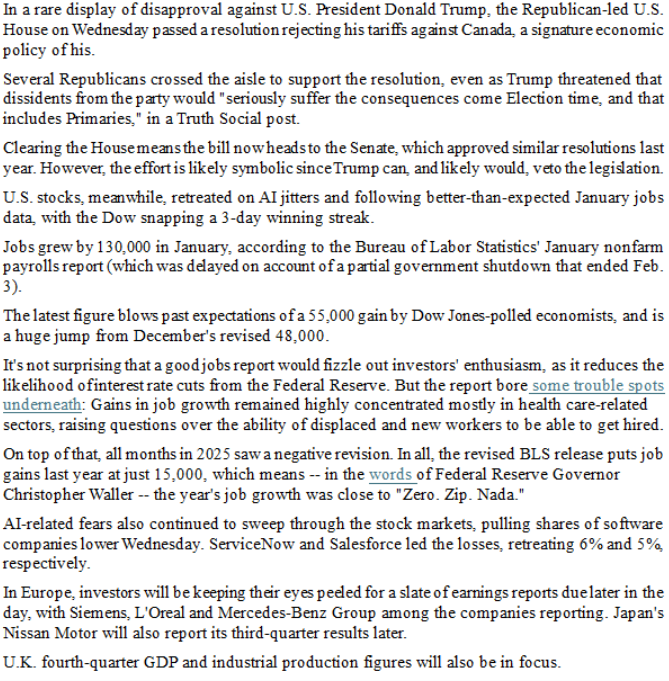

In [ ]:
import re

In [ ]:
text = """In a rare display of disapproval against U.S. President Donald Trump, the Republican-led U.S. House on Wednesday passed a resolution rejecting his tariffs against Canada, a signature economic policy of his.

Several Republicans crossed the aisle to support the resolution, even as Trump threatened that dissidents from the party would "seriously suffer the consequences come Election time, and that includes Primaries," in a Truth Social post.

Clearing the House means the bill now heads to the Senate, which approved similar resolutions last year. However, the effort is likely symbolic since Trump can, and likely would, veto the legislation.

U.S. stocks, meanwhile, retreated on AI jitters and following better-than-expected January jobs data, with the Dow snapping a 3-day winning streak.

Jobs grew by 130,000 in January, according to the Bureau of Labor Statistics' January nonfarm payrolls report (which was delayed on account of a partial government shutdown that ended Feb. 3).

The latest figure blows past expectations of a 55,000 gain by Dow Jones-polled economists, and is a huge jump from December's revised 48,000.

It's not surprising that a good jobs report would fizzle out investors' enthusiasm, as it reduces the likelihood of interest rate cuts from the Federal Reserve. But the report bore some trouble spots underneath: Gains in job growth remained highly concentrated mostly in health care-related sectors, raising questions over the ability of displaced and new workers to be able to get hired.

On top of that, all months in 2025 saw a negative revision. In all, the revised BLS release puts job gains last year at just 15,000, which means -- in the words of Federal Reserve Governor Christopher Waller -- the year's job growth was close to "Zero. Zip. Nada."

AI-related fears also continued to sweep through the stock markets, pulling shares of software companies lower Wednesday. ServiceNow and Salesforce led the losses, retreating 6% and 5%, respectively.

In Europe, investors will be keeping their eyes peeled for a slate of earnings reports due later in the day, with Siemens, L'Oreal and Mercedes-Benz Group among the companies reporting. Japan's Nissan Motor will also report its third-quarter results later.

U.K. fourth-quarter GDP and industrial production figures will also be in focus."""

In [ ]:
print(text)

In a rare display of disapproval against U.S. President Donald Trump, the Republican-led U.S. House on Wednesday passed a resolution rejecting his tariffs against Canada, a signature economic policy of his.

Several Republicans crossed the aisle to support the resolution, even as Trump threatened that dissidents from the party would "seriously suffer the consequences come Election time, and that includes Primaries," in a Truth Social post.

Clearing the House means the bill now heads to the Senate, which approved similar resolutions last year. However, the effort is likely symbolic since Trump can, and likely would, veto the legislation.

U.S. stocks, meanwhile, retreated on AI jitters and following better-than-expected January jobs data, with the Dow snapping a 3-day winning streak.

Jobs grew by 130,000 in January, according to the Bureau of Labor Statistics' January nonfarm payrolls report (which was delayed on account of a partial government shutdown that ended Feb. 3).

The latest

## Extracting Numbers

In [ ]:
numbers = re.findall(r'\d+', text)
print(numbers)

['3', '130', '000', '3', '55', '000', '48', '000', '2025', '15', '000', '6', '5']


`findall` is used to search for all matches of a specific pattern and return them as a list.

- `\d` matches a digit (0–9)  
- `+` means one or more digits  

## Extracting Numbers with Commas

In [ ]:
numbers_commas = re.findall(r'\d{1,3}(?:,\d{3})+', text)
print(numbers_commas)

['130,000', '55,000', '48,000', '15,000']


- `\d{1,3}`  matches the first 1 to 3 digits  
- `(?:,\d{3})+`  matches groups like ",000", ",123" repeated one or more times  

`(?: )`  groups the pattern without capturing it  

We use it because:
- we need grouping for repetition  
- but we want the full number, not just parts of it  

If we remove `?`, we will be using a capturing group instead, and results will return only ",000" rather than full numbers:

In [ ]:
numbers_commas = re.findall(r'\d{1,3}(,\d{3})+', text)
print(numbers_commas)

[',000', ',000', ',000', ',000']


## Extracting All Numbers (With and Without Commas)

In [ ]:
numbers_all = re.findall(r'\d{1,3}(?:,\d{3})+|\d+', text)
print(numbers_all)

['3', '130,000', '3', '55,000', '48,000', '2025', '15,000', '6', '5']


## Extracting Percentages from Text

In [ ]:
percentages = re.findall(r'\d+%', text)
print(percentages)

['6%', '5%']


## Extracting Capitalized Words

In [ ]:
capital_words = re.findall(r'\b[A-Z][a-z]+\b', text)
print(capital_words)

['In', 'President', 'Donald', 'Trump', 'Republican', 'House', 'Wednesday', 'Canada', 'Several', 'Republicans', 'Trump', 'Election', 'Primaries', 'Truth', 'Social', 'Clearing', 'House', 'Senate', 'However', 'Trump', 'January', 'Dow', 'Jobs', 'January', 'Bureau', 'Labor', 'Statistics', 'January', 'Feb', 'The', 'Dow', 'Jones', 'December', 'It', 'Federal', 'Reserve', 'But', 'Gains', 'On', 'In', 'Federal', 'Reserve', 'Governor', 'Christopher', 'Waller', 'Zero', 'Zip', 'Nada', 'Wednesday', 'Salesforce', 'In', 'Europe', 'Siemens', 'Oreal', 'Mercedes', 'Benz', 'Group', 'Japan', 'Nissan', 'Motor']


- `\b` → ensures matching at word boundaries (matching full tokens)
- `[A-Z]` → matches the first uppercase letter  
- `[a-z]+` → matches the rest of the word  

Without `\b`, we might match inside words!
* Example: iPhone will match "Phone" instead of returning no match !

## Extracting Abbreviations & Acronyms

In [ ]:
abbreviations = re.findall(r'\b(?:[A-Z]\.){2,}|[A-Z]{2,}\b', text)
print(abbreviations)

['U.S.', 'U.S.', 'U.S.', 'AI', 'BLS', 'AI', 'U.K.', 'GDP']


- `(?:[A-Z]\.){2,}` matches patterns like `U.S.` (capital letter + dot, repeated)
- `[A-Z]{2,}` matches uppercase words like `AI`, `GDP`
- `|` allows matching either format
- `\b` ensures matching full tokens

## Removing Punctuation & Special Characters

In [ ]:
clean_text = re.sub(r'[^\w\s]', '', text)
print(clean_text)

In a rare display of disapproval against US President Donald Trump the Republicanled US House on Wednesday passed a resolution rejecting his tariffs against Canada a signature economic policy of his

Several Republicans crossed the aisle to support the resolution even as Trump threatened that dissidents from the party would seriously suffer the consequences come Election time and that includes Primaries in a Truth Social post

Clearing the House means the bill now heads to the Senate which approved similar resolutions last year However the effort is likely symbolic since Trump can and likely would veto the legislation

US stocks meanwhile retreated on AI jitters and following betterthanexpected January jobs data with the Dow snapping a 3day winning streak

Jobs grew by 130000 in January according to the Bureau of Labor Statistics January nonfarm payrolls report which was delayed on account of a partial government shutdown that ended Feb 3

The latest figure blows past expectations of a

- `[^\w\s]` matches any character that is NOT:
  - a word character (`\w`: letters, digits, `_`)
  - or whitespace (`\s`)
- `re.sub()` replaces these characters with an empty string

## Normalizing Whitespace

In [ ]:
normalized = re.sub(r'\s+', ' ', clean_text).strip()
print(normalized)

In a rare display of disapproval against US President Donald Trump the Republicanled US House on Wednesday passed a resolution rejecting his tariffs against Canada a signature economic policy of his Several Republicans crossed the aisle to support the resolution even as Trump threatened that dissidents from the party would seriously suffer the consequences come Election time and that includes Primaries in a Truth Social post Clearing the House means the bill now heads to the Senate which approved similar resolutions last year However the effort is likely symbolic since Trump can and likely would veto the legislation US stocks meanwhile retreated on AI jitters and following betterthanexpected January jobs data with the Dow snapping a 3day winning streak Jobs grew by 130000 in January according to the Bureau of Labor Statistics January nonfarm payrolls report which was delayed on account of a partial government shutdown that ended Feb 3 The latest figure blows past expectations of a 5500

- We replace `\s+` one or more whitspace character with a single space (`' '`) : to fix space inside text
- `.strip()`  removes extra spaces at the beginning and end of the text  

## Replacing Numbers with a Placeholder (<NUM>)


In [ ]:
generalized = re.sub(r'\d+', '<NUM>', text)
print(generalized)

In a rare display of disapproval against U.S. President Donald Trump, the Republican-led U.S. House on Wednesday passed a resolution rejecting his tariffs against Canada, a signature economic policy of his.

Several Republicans crossed the aisle to support the resolution, even as Trump threatened that dissidents from the party would "seriously suffer the consequences come Election time, and that includes Primaries," in a Truth Social post.

Clearing the House means the bill now heads to the Senate, which approved similar resolutions last year. However, the effort is likely symbolic since Trump can, and likely would, veto the legislation.

U.S. stocks, meanwhile, retreated on AI jitters and following better-than-expected January jobs data, with the Dow snapping a <NUM>-day winning streak.

Jobs grew by <NUM>,<NUM> in January, according to the Bureau of Labor Statistics' January nonfarm payrolls report (which was delayed on account of a partial government shutdown that ended Feb. <NUM>).

## Replacing Numbers with Commas (Generalization)

In [ ]:
generalized = re.sub(r'\d{1,3}(?:,\d{3})+', '<NUM>', text)
print(generalized)

In a rare display of disapproval against U.S. President Donald Trump, the Republican-led U.S. House on Wednesday passed a resolution rejecting his tariffs against Canada, a signature economic policy of his.

Several Republicans crossed the aisle to support the resolution, even as Trump threatened that dissidents from the party would "seriously suffer the consequences come Election time, and that includes Primaries," in a Truth Social post.

Clearing the House means the bill now heads to the Senate, which approved similar resolutions last year. However, the effort is likely symbolic since Trump can, and likely would, veto the legislation.

U.S. stocks, meanwhile, retreated on AI jitters and following better-than-expected January jobs data, with the Dow snapping a 3-day winning streak.

Jobs grew by <NUM> in January, according to the Bureau of Labor Statistics' January nonfarm payrolls report (which was delayed on account of a partial government shutdown that ended Feb. 3).

The latest f

## Replacing All Numbers (With and Without Commas)


In [ ]:
generalized = re.sub(r'\d{1,3}(?:,\d{3})+|\d+', '<NUM>', text)
print(generalized)

In a rare display of disapproval against U.S. President Donald Trump, the Republican-led U.S. House on Wednesday passed a resolution rejecting his tariffs against Canada, a signature economic policy of his.

Several Republicans crossed the aisle to support the resolution, even as Trump threatened that dissidents from the party would "seriously suffer the consequences come Election time, and that includes Primaries," in a Truth Social post.

Clearing the House means the bill now heads to the Senate, which approved similar resolutions last year. However, the effort is likely symbolic since Trump can, and likely would, veto the legislation.

U.S. stocks, meanwhile, retreated on AI jitters and following better-than-expected January jobs data, with the Dow snapping a <NUM>-day winning streak.

Jobs grew by <NUM> in January, according to the Bureau of Labor Statistics' January nonfarm payrolls report (which was delayed on account of a partial government shutdown that ended Feb. <NUM>).

The 

## Matching the Word "the" regardless of Capitalization

In [ ]:
matches = re.findall(r'\b[tT]he\b', text)
print(matches)

['the', 'the', 'the', 'the', 'the', 'the', 'the', 'the', 'the', 'the', 'the', 'the', 'The', 'the', 'the', 'the', 'the', 'the', 'the', 'the', 'the', 'the', 'the', 'the']


## Extracting Lowercase Words

In [ ]:
words = re.findall(r'\b[a-z][a-z]+\b', normalized)
print(words)

['rare', 'display', 'of', 'disapproval', 'against', 'the', 'on', 'passed', 'resolution', 'rejecting', 'his', 'tariffs', 'against', 'signature', 'economic', 'policy', 'of', 'his', 'crossed', 'the', 'aisle', 'to', 'support', 'the', 'resolution', 'even', 'as', 'threatened', 'that', 'dissidents', 'from', 'the', 'party', 'would', 'seriously', 'suffer', 'the', 'consequences', 'come', 'time', 'and', 'that', 'includes', 'in', 'post', 'the', 'means', 'the', 'bill', 'now', 'heads', 'to', 'the', 'which', 'approved', 'similar', 'resolutions', 'last', 'year', 'the', 'effort', 'is', 'likely', 'symbolic', 'since', 'can', 'and', 'likely', 'would', 'veto', 'the', 'legislation', 'stocks', 'meanwhile', 'retreated', 'on', 'jitters', 'and', 'following', 'betterthanexpected', 'jobs', 'data', 'with', 'the', 'snapping', 'winning', 'streak', 'grew', 'by', 'in', 'according', 'to', 'the', 'of', 'nonfarm', 'payrolls', 'report', 'which', 'was', 'delayed', 'on', 'account', 'of', 'partial', 'government', 'shutdown',

## Extra: Extracting Emails, URLs, Hashtags, and Mentions


In [ ]:
extra = "Contact me at test@email.com or visit https://example.com #NLP @user"

emails = re.findall(r'[\w\.-]+@[\w\.-]+\.\w+', extra)
urls = re.findall(r'https?://[^\s]+', extra)
hashtags = re.findall(r'#\w+', extra)
mentions = re.findall(r'@\w+', extra)

print('Emails:',emails,'\nURLs:', urls,'\nHashtags:', hashtags,'\nMentions:',mentions)

Emails: ['test@email.com'] 
URLs: ['https://example.com'] 
Hashtags: ['#NLP'] 
Mentions: ['@email', '@user']


URLs: `https?://[^\s]+`

- `https?`  matches http or https (`s` is optional)
- `://`  literal part of the URL
- `[^\s]+`  matches everything until a space

Note:
`\/\/` is sometimes used to escape slashes, but in Python raw strings, `//` is sufficient.

---

 *Realized by*  
**Khawla Chrifi Alaoui**

---